### 1. Install & import necessary libraries or packages 

In [ ]:
import warnings
import subprocess
import sys
from pathlib import Path
warnings.filterwarnings("ignore")

# Install packages from requirements.txt
subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay, f1_score,
    precision_recall_curve, average_precision_score, log_loss
)

### 2. Load data set

In [132]:
OUT_DIR = Path(__file__).parent if "__file__" in locals() else Path.cwd()
df = pd.read_csv(OUT_DIR / "Databel.csv")

### 3. Exploratory data analysis

In [ ]:
print(f"\n Dataset shape : {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")

print("Churn distribution")
print(df["Churn Label"].value_counts())
print(df["Churn Label"].value_counts(normalize=True).round(3) * 100, "\n")


 Dataset shape : (6687, 29)
   Columns        : ['Customer ID', 'Churn Label', 'Account Length (in months)', 'Local Calls', 'Local Mins', 'Intl Calls', 'Intl Mins', 'Intl Active', 'Intl Plan', 'Extra International Charges', 'Customer Service Calls', 'Avg Monthly GB Download', 'Unlimited Data Plan', 'Extra Data Charges', 'State', 'Phone Number', 'Gender', 'Age', 'Under 30', 'Senior', 'Group', 'Number of Customers in Group', 'Device Protection & Online Backup', 'Contract Type', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Unnamed: 27', 'Unnamed: 28']

Churn distribution
Churn Label
No     4891
Yes    1796
Name: count, dtype: int64
Churn Label
No     73.1
Yes    26.9
Name: proportion, dtype: float64 



In [134]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing if len(missing) else "None found\n")

print("Data types")
print(df.dtypes.to_string(), "\n")

#column dropping (replaces loop list-comprehension)
df.drop(columns=["Customer ID", "Phone Number"], errors="ignore", inplace=True)

#Extract empty columns caused by trailing commas in CSV that can crash Imputer
df.dropna(axis=1, how="all", inplace=True)


df["Churn"] = (df["Churn Label"].str.strip().str.lower() == "yes").astype(int)
df.drop(columns=["Churn Label"], inplace=True)

Unnamed: 27    4918
Unnamed: 28    4918
dtype: int64
Data types
Customer ID                           object
Churn Label                           object
Account Length (in months)             int64
Local Calls                            int64
Local Mins                           float64
Intl Calls                           float64
Intl Mins                            float64
Intl Active                           object
Intl Plan                             object
Extra International Charges          float64
Customer Service Calls                 int64
Avg Monthly GB Download                int64
Unlimited Data Plan                   object
Extra Data Charges                     int64
State                                 object
Phone Number                          object
Gender                                object
Age                                    int64
Under 30                              object
Senior                                object
Group                               

Plot graph

In [135]:
sns.set_style("whitegrid")
PALETTE   = "#E07B54"
NEG_COLOR = "#4C9BE8"

def show_fig():
    plt.tight_layout()
    plt.show()

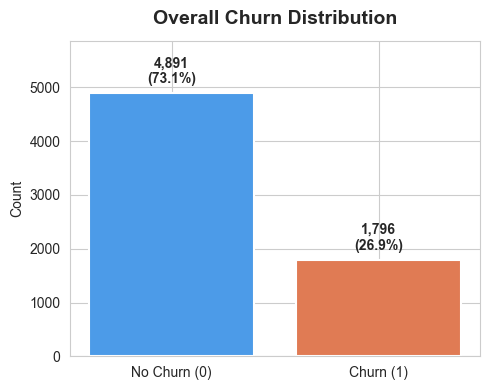

In [136]:
# Plot 1 – Churn distribution
fig, ax = plt.subplots(figsize=(5, 4))
churn_counts = y.value_counts().sort_index()  # sort_index() ensures order: 0=No Churn, 1=Churn
bars = ax.bar(["No Churn (0)", "Churn (1)"], churn_counts.values,
              color=[NEG_COLOR, PALETTE], edgecolor="white", linewidth=1.5)
ax.bar_label(bars, labels=[f"{v:,}\n({v/len(y)*100:.1f}%)" for v in churn_counts.values],
             padding=5, fontsize=10, fontweight="bold")
ax.set_title("Overall Churn Distribution", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Count")
ax.set_ylim(0, churn_counts.max() * 1.2)
show_fig()

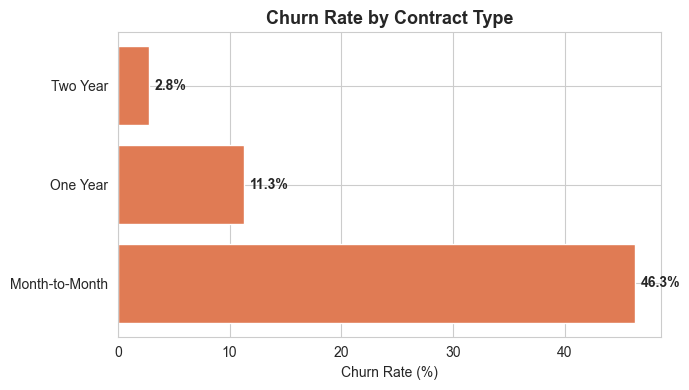

In [137]:
# Plot 2 – Churn by Contract Type
if "Contract Type" in df.columns:
    ct = df.groupby("Contract Type")["Churn"].mean().reset_index()
    ct["Churn%"] = ct["Churn"] * 100
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.barh(ct["Contract Type"], ct["Churn%"], color=PALETTE)
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in ct["Churn%"]],
                 padding=4, fontsize=10, fontweight="bold")
    ax.set_xlabel("Churn Rate (%)")
    ax.set_title("Churn Rate by Contract Type", fontsize=13, fontweight="bold")
    show_fig()

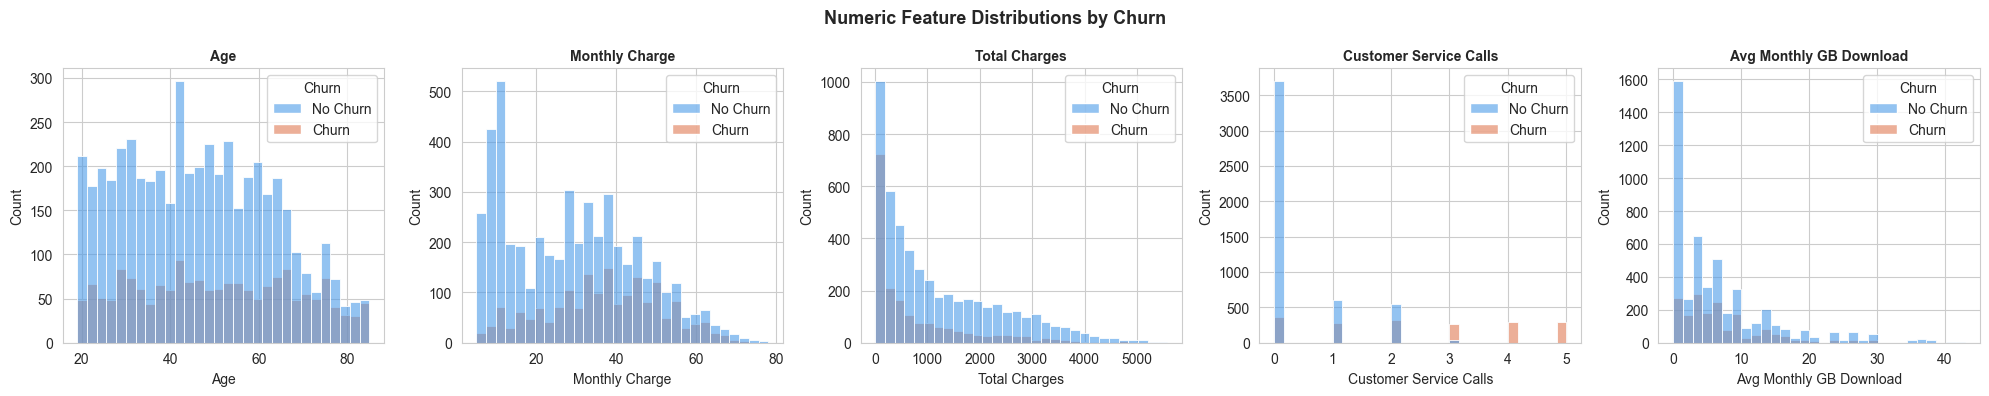

In [138]:
# Plot 3 – Numeric distributions (seaborn histplot with hue)
# Map int > string label once to avoid int palette key mismatch across seaborn versions
CHURN_LABEL_MAP = {0: "No Churn", 1: "Churn"}
CHURN_PALETTE   = {"No Churn": NEG_COLOR, "Churn": PALETTE}
key_num = [c for c in ["Age", "Monthly Charge", "Total Charges", "Customer Service Calls", "Avg Monthly GB Download"] if c in df.columns]
if key_num:
    fig, axes = plt.subplots(1, len(key_num), figsize=(4 * len(key_num), 4))
    if len(key_num) == 1: axes = [axes]
    for ax, col in zip(axes, key_num):
        _df_plot = df[[col, "Churn"]].copy()
        _df_plot["Churn"] = _df_plot["Churn"].map(CHURN_LABEL_MAP)
        sns.histplot(data=_df_plot, x=col, hue="Churn", ax=ax, bins=30,
                     palette=CHURN_PALETTE, hue_order=["No Churn", "Churn"],
                     alpha=0.6, element="bars")
        ax.set_title(col, fontsize=10, fontweight="bold")
    fig.suptitle("Numeric Feature Distributions by Churn", fontweight="bold", fontsize=13)
    show_fig()

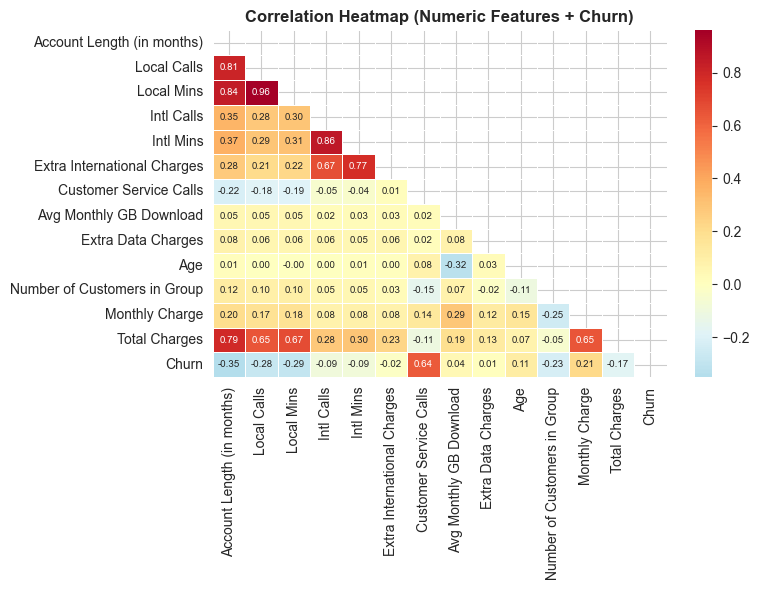

In [139]:
# Plot 4 – Correlation heatmap
if len(num_cols) > 1:
    sz = max(8, len(num_cols) // 2)
    fig, ax = plt.subplots(figsize=(sz, sz - 2))
    corr_data = df[num_cols + ["Churn"]].corr()
    mask = np.triu(np.ones_like(corr_data, dtype=bool))
    sns.heatmap(corr_data, mask=mask, annot=True, fmt=".2f",
                cmap="RdYlBu_r", center=0, ax=ax,
                annot_kws={"size": 7}, linewidths=0.5)
    ax.set_title("Correlation Heatmap (Numeric Features + Churn)", fontweight="bold", fontsize=12)
    show_fig()

### 4. Look outlier

In [140]:
print("Outlier Detection (using 1.5 * IQR method)")
outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    if outlier_count > 0:
        churn_rate = outliers["Churn"].mean() * 100
        normal_churn = df[~((df[col] < lower_bound) | (df[col] > upper_bound))]["Churn"].mean() * 100
        outlier_summary.append({
            "Feature": col,
            "Outliers": outlier_count,
            "Outlier %": round(outlier_count / len(df) * 100, 2),
            "Churn% (Outlier)": round(churn_rate, 2),
            "Churn% (Normal)": round(normal_churn, 2)
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary).sort_values("Outlier %", ascending=False)
    print(outlier_df.to_string(index=False), "\n")
else:
    print("No significant outliers detected based on IQR.\n")

Outlier Detection (using 1.5 * IQR method)
                     Feature  Outliers  Outlier %  Churn% (Outlier)  Churn% (Normal)
Number of Customers in Group      1521      22.75              6.51            32.85
 Extra International Charges      1366      20.43             29.14            26.27
                  Intl Calls      1085      16.23             16.77            28.81
                   Intl Mins      1076      16.09             17.38            28.68
          Extra Data Charges       688      10.29             32.85            26.17
     Avg Monthly GB Download       365       5.46             21.37            27.17
                 Local Calls       124       1.85              5.65            27.26
               Total Charges       123       1.84             13.82            27.10
                  Local Mins        38       0.57              0.00            27.01 



Outlier Insights:
- Outliers in variables like 'Customer Service Calls' or 'Extra Data Charges' often indicate severe dissatisfaction (e.g. repeated issues or bill shock), which typically directly correlates with a surge in churn probability.
- They are automatically handled in the model pipeline using RobustScaler() to ensure these extreme values don't warp our Logistic Regression decision boundaries.

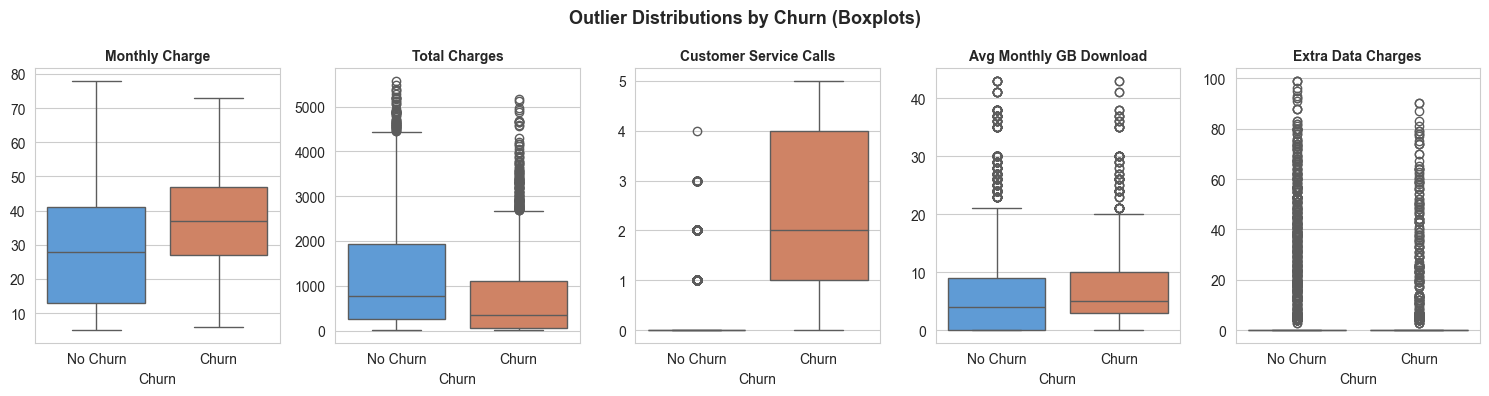

In [ ]:
# Plot 3b – Outlier Boxplots
box_cols = [c for c in ["Monthly Charge", "Total Charges", "Customer Service Calls", "Avg Monthly GB Download", "Extra Data Charges"] if c in df.columns]
if box_cols:
    fig, axes = plt.subplots(1, len(box_cols), figsize=(3 * len(box_cols), 4))
    if len(box_cols) == 1: axes = [axes]
    for ax, col in zip(axes, box_cols):
        _x_label = df["Churn"].map(CHURN_LABEL_MAP)  # np.int64 > plain string
        sns.boxplot(y=df[col], x=_x_label, ax=ax,
                    palette=CHURN_PALETTE, order=["No Churn", "Churn"])
        ax.set_title(col, fontsize=10, fontweight="bold")
        ax.set_ylabel("")
    fig.suptitle("Outlier Distributions by Churn (Boxplots)", fontweight="bold", fontsize=13)
    show_fig()

### 5. Select feature

In [142]:
# Drop the predicted target column
y = df["Churn"]
X = df.drop(columns=["Churn"])
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numeric  features ({len(num_cols)}): {num_cols}")
print(f"Categoric features ({len(cat_cols)}): {cat_cols}\n")

Numeric  features (13): ['Account Length (in months)', 'Local Calls', 'Local Mins', 'Intl Calls', 'Intl Mins', 'Extra International Charges', 'Customer Service Calls', 'Avg Monthly GB Download', 'Extra Data Charges', 'Age', 'Number of Customers in Group', 'Monthly Charge', 'Total Charges']
Categoric features (13): ['Intl Active', 'Intl Plan', 'Unlimited Data Plan', 'State', 'Gender', 'Under 30', 'Senior', 'Group', 'Device Protection & Online Backup', 'Contract Type', 'Payment Method', 'Unnamed: 27', 'Unnamed: 28']



### 6. Data preprocessing

In [143]:
# separate data in train, test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n Train size : {X_train.shape[0]}  |  Test size : {X_test.shape[0]}")
print(f"\n Train churn: {y_train.mean():.3%}  |  Test churn: {y_test.mean():.3%}\n")


 Train size : 5349  |  Test size : 1338

 Train churn: 26.865%  |  Test churn: 26.831%



### 7. Build pipeline
prevent data set leak from train, test split

In [144]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler",  StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))]), cat_cols)
])

pipeline_baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=2000, random_state=42))
])
pipeline_baseline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 8. Base model performance

In [145]:
y_pred_base_pre      = pipeline_baseline.predict(X_test)
y_pred_base_pre_prob = pipeline_baseline.predict_proba(X_test)[:, 1]

acc_base  = accuracy_score(y_test, y_pred_base_pre)
auc_base  = roc_auc_score(y_test, y_pred_base_pre_prob)
f1_base   = f1_score(y_test, y_pred_base_pre)
loss_base = log_loss(y_test, y_pred_base_pre_prob)

print("\n" + "═" * 60)
print("BASE MODEL PERFORMANCE  (L2, C=1.0 no tuning)")
print("═" * 60)
print(f"Accuracy  : {acc_base:.4f}")
print(f"ROC-AUC   : {auc_base:.4f}")
print(f"F1-Score  : {f1_base:.4f}")
print(f"Log-Loss  : {loss_base:.4f}")
print(f"\n{classification_report(y_test, y_pred_base_pre, target_names=['No Churn', 'Churn'])}")


════════════════════════════════════════════════════════════
BASE MODEL PERFORMANCE  (L2, C=1.0 no tuning)
════════════════════════════════════════════════════════════
Accuracy  : 0.9664
ROC-AUC   : 0.9909
F1-Score  : 0.9349
Log-Loss  : 0.0867

              precision    recall  f1-score   support

    No Churn       0.96      0.99      0.98       979
       Churn       0.97      0.90      0.93       359

    accuracy                           0.97      1338
   macro avg       0.97      0.95      0.96      1338
weighted avg       0.97      0.97      0.97      1338



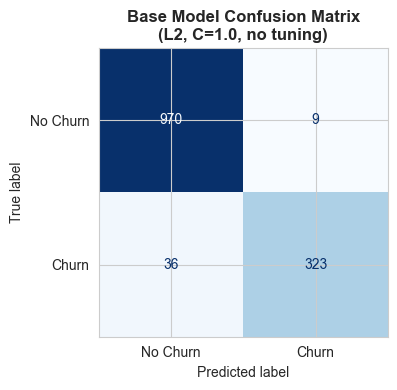

In [146]:
# Plot 5a – Base Model Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_base_pre),
    display_labels=["No Churn", "Churn"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Base Model Confusion Matrix\n(L2, C=1.0, no tuning)", fontweight="bold")
show_fig()

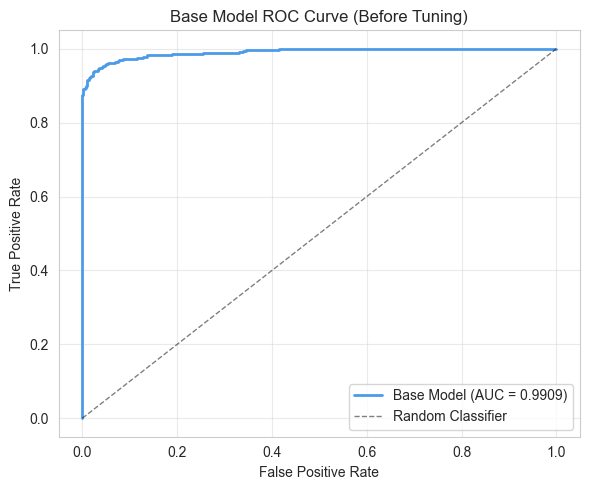

In [147]:
# Plot 5b – Base Model ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
fpr_base_pre, tpr_base_pre, _ = roc_curve(y_test, y_pred_base_pre_prob)
ax.plot(fpr_base_pre, tpr_base_pre, color=NEG_COLOR, lw=2,
        label=f"Base Model (AUC = {auc_base:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random Classifier")
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
       title="Base Model ROC Curve (Before Tuning)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
show_fig()

### 9. BIAS-VARIANCE diagnosis  (Underfit / Good Fit / Overfit check)

In [ ]:
# Train vs Test metric gap 
acc_train = accuracy_score(y_train, pipeline_baseline.predict(X_train))
auc_train = roc_auc_score(y_train, pipeline_baseline.predict_proba(X_train)[:, 1])
f1_train  = f1_score(y_train, pipeline_baseline.predict(X_train))

gap_acc = acc_train - acc_base    # positive = model fits train better > overfit risk
gap_auc = auc_train - auc_base
gap_f1  = f1_train  - f1_base

print("\n" + "═" * 60)
print("  BIAS-VARIANCE / FIT DIAGNOSIS (Base Model)")
print("═" * 60)
print(f"{'Metric':<12} {'Train':>8}  {'Test':>8}  {'Gap (Train-Test)':>18}")
print(f"{'-'*12} {'-'*8}  {'-'*8}  {'-'*18}")
print(f"{'Accuracy':<12} {acc_train:>8.3f}  {acc_base:>8.3f}  {gap_acc:>+18.3f}")
print(f"{'ROC-AUC':<12} {auc_train:>8.3f}  {auc_base:>8.3f}  {gap_auc:>+18.3f}")
print(f"{'F1-Score':<12} {f1_train:>8.3f}  {f1_base:>8.3f}  {gap_f1:>+18.3f}")


════════════════════════════════════════════════════════════
  BIAS-VARIANCE / FIT DIAGNOSIS (Base Model)
════════════════════════════════════════════════════════════
  Metric          Train      Test    Gap (Train-Test)
  ------------ --------  --------  ------------------
  Accuracy        0.973     0.966              +0.006
  ROC-AUC         0.993     0.991              +0.002
  F1-Score        0.947     0.935              +0.012


In [ ]:
# Cross-Validation stability
cv_scores = cross_val_score(pipeline_baseline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
cv_mean, cv_std = cv_scores.mean(), cv_scores.std()
print(f"\n  5-Fold CV ROC-AUC : {cv_mean:.3f} ± {cv_std:.3f}")
print(f"CV scores : {np.round(cv_scores, 4).tolist()}")


  5-Fold CV ROC-AUC : 0.991 ± 0.002
  CV scores         : [0.9926, 0.9884, 0.9913, 0.9884, 0.9943]


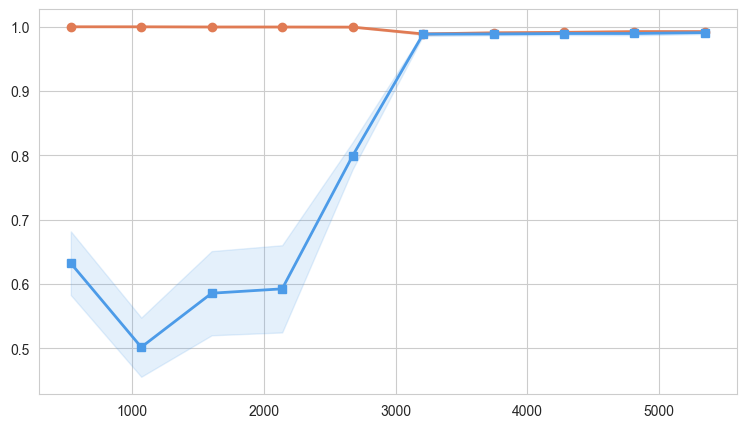

In [ ]:
# Learning Curve plot
lc_results = learning_curve(
    pipeline_baseline, X, y,
    cv=cv, scoring="roc_auc", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)   # 10 % > 100 % of training data
)
train_sizes, lc_train_scores, lc_val_scores = lc_results[:3]

lc_train_mean = lc_train_scores.mean(axis=1)
lc_train_std  = lc_train_scores.std(axis=1)
lc_val_mean   = lc_val_scores.mean(axis=1)
lc_val_std    = lc_val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, lc_train_mean, "o-", color=PALETTE,   lw=2, label="Train ROC-AUC")
ax.plot(train_sizes, lc_val_mean, "s-", color=NEG_COLOR, lw=2, label="CV Val ROC-AUC")
ax.fill_between(train_sizes,
                lc_train_mean - lc_train_std,
                lc_train_mean + lc_train_std, alpha=0.15, color=PALETTE)
ax.fill_between(train_sizes,
                lc_val_mean - lc_val_std,
                lc_val_mean + lc_val_std, alpha=0.15, color=NEG_COLOR)

In [155]:
# Annotate final gap
final_gap = lc_train_mean[-1] - lc_val_mean[-1]
ax.annotate(f"Final gap = {final_gap:+.4f}",
            xy=(train_sizes[-1], (lc_train_mean[-1] + lc_val_mean[-1]) / 2),
            xytext=(train_sizes[-1] * 0.7, (lc_train_mean[-1] + lc_val_mean[-1]) / 2 - 0.01),
            arrowprops=dict(arrowstyle="->", color="gray"),
            fontsize=9, color="gray", fontweight="bold")

ax.set_xlabel("Training Set Size (samples)", fontsize=11)
ax.set_ylabel("ROC-AUC Score")
ax.set_title("Learning Curve Bias-Variance Diagnosis (Base Model)",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)

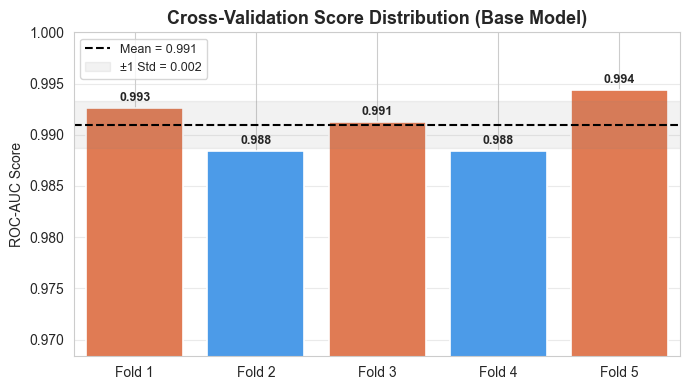

In [156]:
#CV Score Distribution plot
fig, ax = plt.subplots(figsize=(7, 4))
fold_labels = [f"Fold {i+1}" for i in range(len(cv_scores))]
bar_colors  = [PALETTE if s >= cv_mean else NEG_COLOR for s in cv_scores]
bars = ax.bar(fold_labels, cv_scores, color=bar_colors, edgecolor="white", linewidth=1.2)
ax.bar_label(bars, labels=[f"{s:.3f}" for s in cv_scores],
             padding=3, fontsize=9, fontweight="bold")
ax.axhline(cv_mean, color="black", linewidth=1.5, linestyle="--",
           label=f"Mean = {cv_mean:.3f}")
ax.fill_between(range(-1, len(cv_scores) + 1),
                cv_mean - cv_std, cv_mean + cv_std,
                alpha=0.1, color="gray", label=f"±1 Std = {cv_std:.3f}")
ax.set_xlim(-0.5, len(cv_scores) - 0.5)
ax.set_ylim(max(0, cv_scores.min() - 0.02), min(1, cv_scores.max() + 0.04))
ax.set_ylabel("ROC-AUC Score")
ax.set_title("Cross-Validation Score Distribution (Base Model)",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.4)
show_fig()

### 10. Tuning model

Since Logistic Regression involves relatively few hyperparameters to tune, applying Grid Search allows for the optimal values to be identified efficiently and with greater precision.

In [157]:
C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

gs_l2 = GridSearchCV(
    Pipeline([("preprocessor", preprocessor),
              ("classifier", LogisticRegression(penalty="l2", solver="lbfgs", max_iter=2000, random_state=42, class_weight="balanced"))]),
    param_grid={"classifier__C": C_values},
    cv=cv, scoring="roc_auc", refit=True, n_jobs=-1
)
gs_l2.fit(X_train, y_train)

gs_l1 = GridSearchCV(
    Pipeline([("preprocessor", preprocessor),
              ("classifier", LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000, random_state=42, class_weight="balanced"))]),
    param_grid={"classifier__C": C_values},
    cv=cv, scoring="roc_auc", refit=True, n_jobs=-1
)
gs_l1.fit(X_train, y_train)

gs_en = GridSearchCV(
    Pipeline([("preprocessor", preprocessor),
              ("classifier", SGDClassifier(loss="log_loss", penalty="elasticnet", max_iter=2000, random_state=42, tol=1e-4, class_weight="balanced"))]),
    param_grid={
        "classifier__alpha": [0.0001, 0.001, 0.01],
        "classifier__l1_ratio": [0.15, 0.5, 0.85]
    },
    cv=cv, scoring="roc_auc", refit=True, n_jobs=-1
)
gs_en.fit(X_train, y_train)

,estimator,Pipeline(step...tol=0.0001))])
,param_grid,"{'classifier__alpha': [0.0001, 0.001, ...], 'classifier__l1_ratio': [0.15, 0.5, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [159]:
print("═" * 70)
print("REGULARIZATION SEARCH RESULTS (GridSearchCV, 5-Fold CV)")
print("═" * 70)
print(f"L2 best > C={gs_l2.best_params_['classifier__C']:.4f}  AUC={gs_l2.best_score_:.3f}")
print(f"L1 best > C={gs_l1.best_params_['classifier__C']:.4f}  AUC={gs_l1.best_score_:.3f}")
print(f"ElasticNet best > alpha={gs_en.best_params_['classifier__alpha']}  l1_ratio={gs_en.best_params_['classifier__l1_ratio']}  AUC={gs_en.best_score_:.3f}")

best_gs       = max([gs_l2, gs_l1, gs_en], key=lambda g: g.best_score_)
pipeline_best = best_gs.best_estimator_
print(f"\n Best overall > AUC={best_gs.best_score_:.3f}  params={best_gs.best_params_}\n")

══════════════════════════════════════════════════════════════════════
REGULARIZATION SEARCH RESULTS (GridSearchCV, 5-Fold CV)
══════════════════════════════════════════════════════════════════════
L2 best > C=0.5000  AUC=0.991
L1 best > C=0.5000  AUC=0.992
ElasticNet best > alpha=0.001  l1_ratio=0.85  AUC=0.992

 Best overall > AUC=0.992  params={'classifier__C': 0.5}



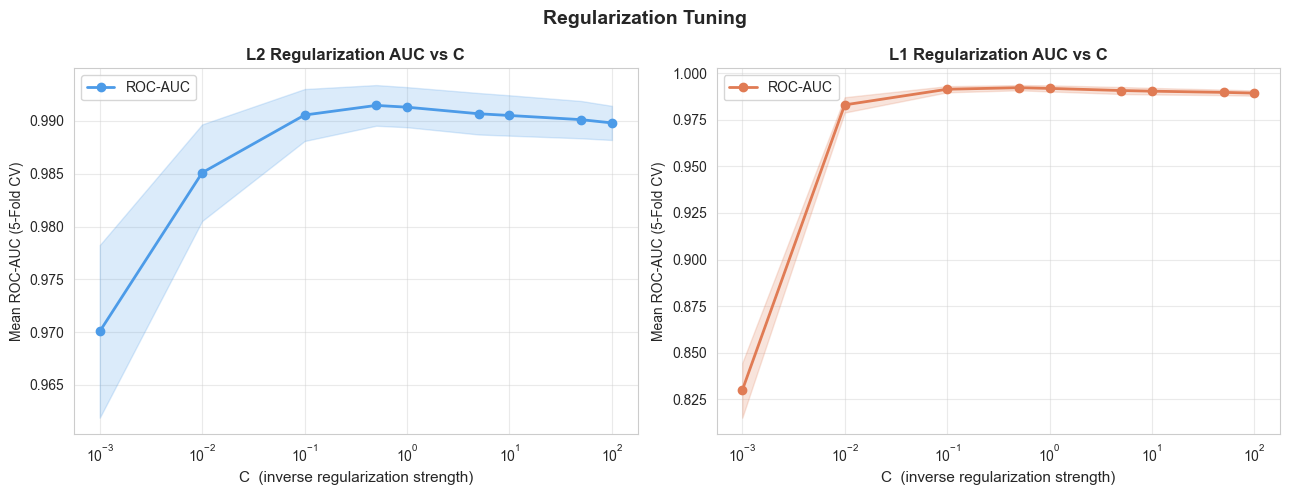

In [160]:
# Plot 5 – Regularization curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, gs, color, label in [(axes[0], gs_l2, "#4C9BE8", "L2"), (axes[1], gs_l1, "#E07B54", "L1")]:
    res = pd.DataFrame(gs.cv_results_)
    ax.semilogx(res["param_classifier__C"].astype(float), res["mean_test_score"], "o-", color=color, linewidth=2, markersize=6, label="ROC-AUC")
    ax.fill_between(res["param_classifier__C"].astype(float),
                    res["mean_test_score"] - res["std_test_score"],
                    res["mean_test_score"] + res["std_test_score"], alpha=0.2, color=color)
    ax.set_xlabel("C  (inverse regularization strength)", fontsize=11)
    ax.set_ylabel("Mean ROC-AUC (5-Fold CV)")
    ax.set_title(f"{label} Regularization AUC vs C", fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.4)
plt.suptitle("Regularization Tuning", fontsize=14, fontweight="bold")
show_fig()

Gradient descent learning curve  (SGD epoch-by-epoch log-loss):<br> 
to find the best parameter for model

In [161]:
# Extract the already-fitted preprocessor from best pipeline (avoids re-fitting / data leakage)
_pre_fitted = pipeline_best.named_steps["preprocessor"]
X_train_t = _pre_fitted.transform(X_train)
X_test_t  = _pre_fitted.transform(X_test)

best_C_l2 = gs_l2.best_params_["classifier__C"]

In [162]:
# CORRECTED METRIC: For SGDClassifier penalty 'l2', alpha is proportional to 1 / (C * n_samples)
alpha_val = 1.0 / (best_C_l2 * X_train_t.shape[0])

# compute_class_weight is required because class_weight="balanced" is NOT supported with partial_fit()
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))  # {0: w0, 1: w1}

sgd_gd = SGDClassifier(loss="log_loss", penalty="l2", alpha=alpha_val,
                       warm_start=True, random_state=42,
                       tol=None, class_weight=class_weight_dict)

train_losses, val_losses = [], []

In [163]:
# REPLACED .fit() (which resets the model each iteration) with .partial_fit()
for epoch in range(80):
    sgd_gd.partial_fit(X_train_t, y_train, classes=classes)
    train_losses.append(log_loss(y_train, sgd_gd.predict_proba(X_train_t)))
    val_losses.append(log_loss(y_test,   sgd_gd.predict_proba(X_test_t)))


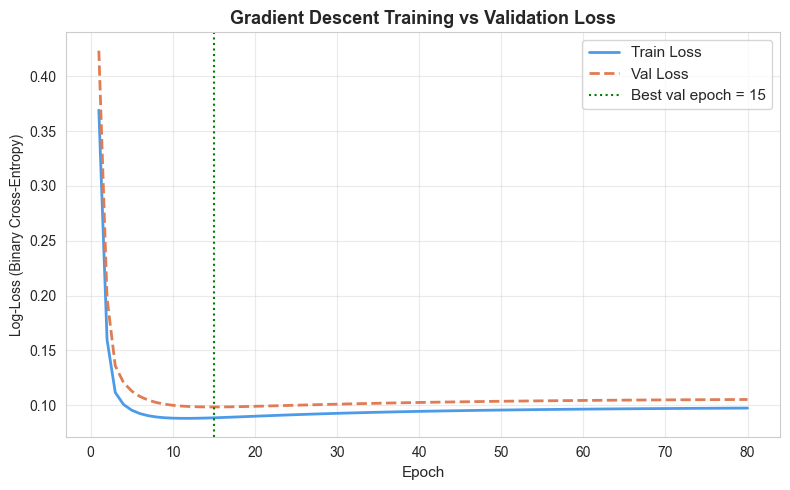

In [164]:
est_epoch = int(np.argmin(val_losses)) + 1
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 81), train_losses, label="Train Loss", color="#4C9BE8", linewidth=2)
ax.plot(range(1, 81), val_losses, label="Val Loss", color="#E07B54", linewidth=2, linestyle="--")
ax.axvline(best_epoch, color="green", linestyle=":", linewidth=1.5, label=f"Best val epoch = {best_epoch}")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Log-Loss (Binary Cross-Entropy)")
ax.set_title("Gradient Descent Training vs Validation Loss", fontweight="bold", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
show_fig()

### 11. Evaluate the model 

In [165]:
y_pred           = pipeline_best.predict(X_test)
y_pred_prob      = pipeline_best.predict_proba(X_test)[:, 1]
y_pred_base      = pipeline_baseline.predict(X_test)
y_pred_base_prob = pipeline_baseline.predict_proba(X_test)[:, 1]

In [ ]:
print("\n" + "═" * 60)
print("BEST MODEL PERFORMANCE ON TEST SET")
print("═" * 60)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])}")


════════════════════════════════════════════════════════════
  BEST MODEL PERFORMANCE ON TEST SET
════════════════════════════════════════════════════════════
Accuracy : 0.9664
ROC-AUC  : 0.9913
F1-Score : 0.9374

              precision    recall  f1-score   support

    No Churn       0.98      0.98      0.98       979
       Churn       0.94      0.94      0.94       359

    accuracy                           0.97      1338
   macro avg       0.96      0.96      0.96      1338
weighted avg       0.97      0.97      0.97      1338



In [167]:
# Before-vs-After Tuning Comparison 
acc_tuned  = accuracy_score(y_test, y_pred)
auc_tuned  = roc_auc_score(y_test, y_pred_prob)
f1_tuned   = f1_score(y_test, y_pred)
loss_tuned = log_loss(y_test, y_pred_prob)

metrics_df = pd.DataFrame({
    "Before Tuning (Base)": [acc_base,  auc_base,  f1_base,  loss_base],
    "After Tuning (Best)":  [acc_tuned, auc_tuned, f1_tuned, loss_tuned],
    "Δ Change":             [acc_tuned  - acc_base,
                             auc_tuned  - auc_base,
                             f1_tuned   - f1_base,
                             loss_tuned - loss_base],
}, index=["Accuracy", "ROC-AUC", "F1-Score", "Log-Loss"])
metrics_df["Δ Change"] = metrics_df["Δ Change"].map(lambda v: f"+{v:.3f}" if v > 0 else f"{v:.3f}")

In [ ]:
print("═" * 60)
print("BEFORE vs AFTER TUNING FULL COMPARISON")
print("═" * 60)
print(metrics_df.round(3).to_string())
print()
print("Interpretation:")
print(f"Accuracy  : {acc_base:.3f} > {acc_tuned:.3f}  ({'+' if acc_tuned >= acc_base else ''}{acc_tuned - acc_base:+.3f})")
print(f"ROC-AUC   : {auc_base:.3f} > {auc_tuned:.3f}  ({'+' if auc_tuned >= auc_base else ''}{auc_tuned - auc_base:+.3f})")
print(f"F1-Score  : {f1_base:.3f} > {f1_tuned:.3f}  ({'+' if f1_tuned >= f1_base else ''}{f1_tuned - f1_base:+.3f})")
print(f"Log-Loss  : {loss_base:.3f} > {loss_tuned:.3f}  ({'+' if loss_tuned >= loss_base else ''}{loss_tuned - loss_base:+.3f}) lower is better")
print()

════════════════════════════════════════════════════════════
  BEFORE vs AFTER TUNING FULL COMPARISON
════════════════════════════════════════════════════════════
          Before Tuning (Base)  After Tuning (Best) Δ Change
Accuracy                 0.966                0.966    0.000
ROC-AUC                  0.991                0.991   +0.000
F1-Score                 0.935                0.937   +0.003
Log-Loss                 0.087                0.097   +0.010

Interpretation:
Accuracy  : 0.966 > 0.966  (++0.000)
ROC-AUC   : 0.991 > 0.991  (++0.000)
F1-Score  : 0.935 > 0.937  (++0.003)
Log-Loss  : 0.087 > 0.097  (++0.010) lower is better



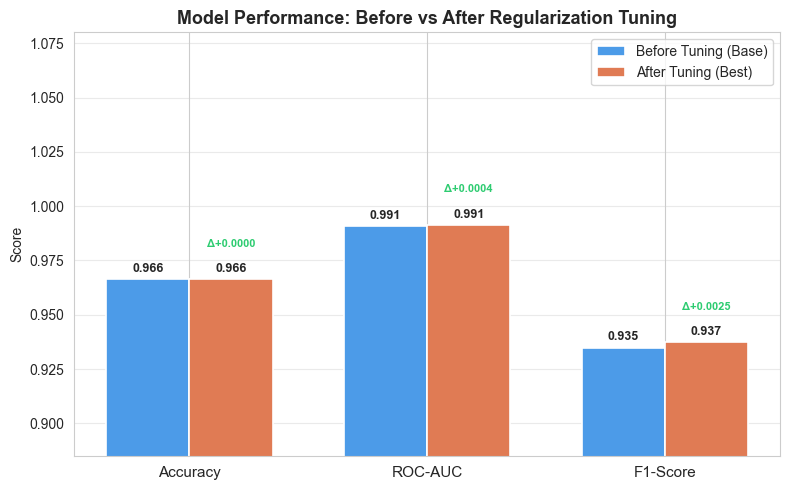

In [170]:
# Plot 7a – Before-vs-After Metric Bar Chart
metric_labels = ["Accuracy", "ROC-AUC", "F1-Score"]
before_vals = [acc_base,  auc_base,  f1_base]
after_vals  = [acc_tuned, auc_tuned, f1_tuned]
x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_b = ax.bar(x - width/2, before_vals, width, label="Before Tuning (Base)",
                color=NEG_COLOR, edgecolor="white", linewidth=1.2)
bars_t = ax.bar(x + width/2, after_vals,  width, label="After Tuning (Best)",
                color=PALETTE,  edgecolor="white", linewidth=1.2)

ax.bar_label(bars_b, labels=[f"{v:.3f}" for v in before_vals],
             padding=3, fontsize=9, fontweight="bold")
ax.bar_label(bars_t, labels=[f"{v:.3f}" for v in after_vals],
             padding=3, fontsize=9, fontweight="bold")

for i, (bv, tv) in enumerate(zip(before_vals, after_vals)):
    delta = tv - bv
    arrow_color = "#2ecc71" if delta >= 0 else "#e74c3c"
    ax.annotate(f"Δ{delta:+.4f}",
                xy=(x[i] + width/2, tv),
                xytext=(x[i] + width/2, tv + 0.015),
                ha="center", fontsize=8, color=arrow_color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(min(min(before_vals), min(after_vals)) - 0.05, 1.08)
ax.set_ylabel("Score")
ax.set_title("Model Performance: Before vs After Regularization Tuning",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.4)
show_fig()

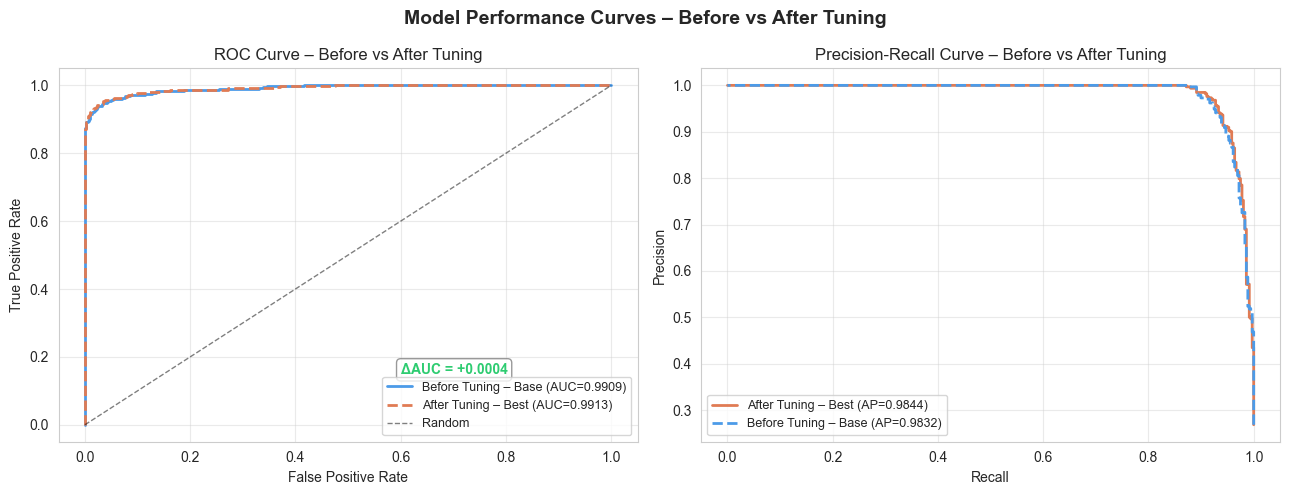

In [ ]:
# Plot 7b – ROC + Precision-Recall curves (Before vs After)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr_b, tpr_b, _ = roc_curve(y_test, y_pred_base_prob)
fpr_t, tpr_t, _ = roc_curve(y_test, y_pred_prob)
auc_b = roc_auc_score(y_test, y_pred_base_prob)
auc_t = roc_auc_score(y_test, y_pred_prob)

axes[0].plot(fpr_b, tpr_b, color=NEG_COLOR, lw=2,
             label=f"Before Tuning – Base (AUC={auc_b:.4f})")
axes[0].plot(fpr_t, tpr_t, color=PALETTE,   lw=2, linestyle="--",
             label=f"After Tuning – Best (AUC={auc_t:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate",
            title="ROC Curve – Before vs After Tuning")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)
# Annotate AUC gain
axes[0].annotate(f"ΔAUC = {auc_t - auc_b:+.3f}",
                 xy=(0.6, 0.15), fontsize=10, color="#2ecc71" if auc_t >= auc_b else "#e74c3c",
                 fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8))

prec, rec,   _ = precision_recall_curve(y_test, y_pred_prob)
prec_b, rec_b, _ = precision_recall_curve(y_test, y_pred_base_prob)
avg_prec   = average_precision_score(y_test, y_pred_prob)
avg_prec_b = average_precision_score(y_test, y_pred_base_prob)

axes[1].plot(rec,   prec,   color=PALETTE,   lw=2,
             label=f"After Tuning Best (AP={avg_prec:.3f})")
axes[1].plot(rec_b, prec_b, color=NEG_COLOR, lw=2, linestyle="--",
             label=f"Before Tuning Base (AP={avg_prec_b:.3f})")
axes[1].set(xlabel="Recall", ylabel="Precision",
            title="Precision-Recall Curve Before vs After Tuning")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)
axes[1].annotate(f"ΔAP = {avg_prec - avg_prec_b:+.3f}",
                 xy=(0.05, 0.15), fontsize=10,
                 color="#2ecc71" if avg_prec >= avg_prec_b else "#e74c3c",
                 fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8))

plt.suptitle("Model Performance Curves Before vs After Tuning",
             fontsize=14, fontweight="bold")
show_fig()

### 12. Result for customer identification (Base vs Best Model)
best model = tuned model

In [171]:
risk_df = X_test.copy().reset_index(drop=True)
risk_df["Churn_Probability_Base"] = y_pred_base_prob
risk_df["Churn_Probability_Best"] = y_pred_prob

bins = [0, 0.3, 0.5, 0.7, 1.0]
labels = ["Low (<30%)", "Medium (30-50%)", "High (50-70%)", "Very High (>70%)"]

risk_df["Risk_Tier_Base"] = pd.cut(risk_df["Churn_Probability_Base"], bins=bins, labels=labels)
risk_df["Risk_Tier_Best"] = pd.cut(risk_df["Churn_Probability_Best"], bins=bins, labels=labels)

tier_counts_base = risk_df["Risk_Tier_Base"].value_counts().sort_index()
tier_counts_best = risk_df["Risk_Tier_Best"].value_counts().sort_index()

In [172]:
# Consolidated Summary Table
summary_df = pd.DataFrame({
    "Base Model (Count)": tier_counts_base,
    "Best Model (Count)": tier_counts_best,
    "Difference (Best - Base)": tier_counts_best - tier_counts_base
})

print("\n" + "═" * 60)
print("AT-RISK CUSTOMER TIER SUMMARY: BASE vs BEST")
print("═" * 60)
print(summary_df.to_string())

v_high_base = tier_counts_base.iloc[-1]
v_high_best = tier_counts_best.iloc[-1]
print(f"\n Very High Risk (>70%) : Base = {v_high_base} | Best = {v_high_best}\n")


════════════════════════════════════════════════════════════
AT-RISK CUSTOMER TIER SUMMARY: BASE vs BEST
════════════════════════════════════════════════════════════
                  Base Model (Count)  Best Model (Count)  Difference (Best - Base)
Low (<30%)                       979                 942                       -37
Medium (30-50%)                   27                  36                         9
High (50-70%)                     14                  23                         9
Very High (>70%)                 318                 337                        19

 Very High Risk (>70%) : Base = 318 | Best = 337



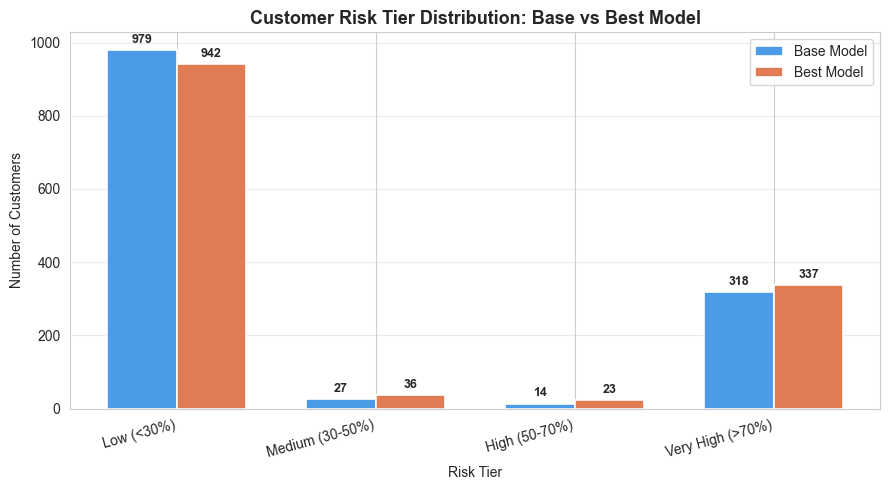

In [130]:
# Comparison Graph
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(labels))
width = 0.35

bars_b = ax.bar(x - width/2, tier_counts_base, width, label="Base Model",
                color=NEG_COLOR, edgecolor="white", linewidth=1.2)
bars_t = ax.bar(x + width/2, tier_counts_best, width, label="Best Model",
                color=PALETTE, edgecolor="white", linewidth=1.2)

ax.bar_label(bars_b, padding=3, fontsize=9, fontweight="bold")
ax.bar_label(bars_t, padding=3, fontsize=9, fontweight="bold")

ax.set_title("Customer Risk Tier Distribution: Base vs Best Model", fontweight="bold", fontsize=13)
ax.set(xlabel="Risk Tier", ylabel="Number of Customers")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.4)
show_fig()
print()